In [96]:
import pandas as pd

df = pd.read_excel("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [97]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [98]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [99]:
#remove rows without customerID
df = df[df['CustomerID'].notnull()]
df.shape

(406829, 8)

In [100]:
#check for negative Quantity
df[df['Quantity'] <0 ].shape


(8905, 8)

In [101]:
#clean

df = df[df['Quantity'] > 0 ]

df.shape

(397924, 8)

In [102]:
#remove negative price
df = df[df['UnitPrice'] > 0]

In [103]:
#create revenue column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [104]:
print(df.shape)

(397884, 9)


/var/folders/wd/cv2f7dtd0y3ghh2y0s0bdt0r0000gn/T/ipykernel_96033/3200618460.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.set_index('InvoiceDate').resample('M')['TotalPrice'].sum()


<Axes: xlabel='InvoiceDate'>

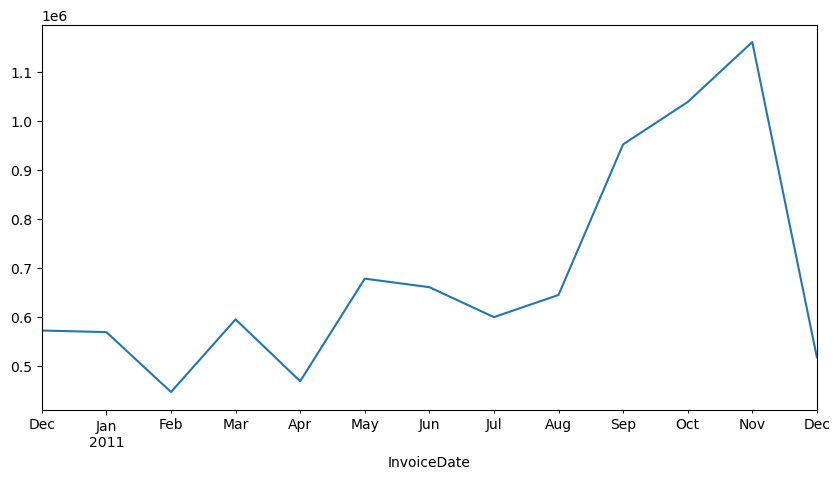

In [105]:
monthly_sales = df.set_index('InvoiceDate').resample('M')['TotalPrice'].sum()
monthly_sales.plot(figsize=(10,5))


In [107]:
df.to_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/clean_transactions.csv", index=False)